In [1]:
ls ..

benchmarks/   examples/  Makefile        python/                src/
build/        include/   nvblas.conf     README.md              tests/
CITATION.bib  LICENSE    pyproject.toml  requirements.test.txt


In [2]:
# nvblas setup
import os
# Must be set before libtrexdiff.so is loaded.
os.environ.setdefault(
    'NVBLAS_CONFIG_FILE',
    str('../nvblas.conf'),
)

'../nvblas.conf'

In [3]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from sklearn import datasets, metrics, linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

In [4]:
digits = datasets.fetch_openml('mnist_784', version=1)

In [5]:
digits.images = digits['data'].to_numpy().reshape(-1, 28, 28)
digits.target = digits['target'].to_numpy().astype(int)

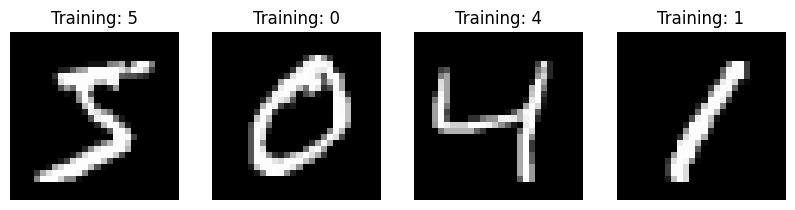

In [6]:
# digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray)
    ax.set_title("Training: %i" % label)


# Baseline (from sklearn)

In [7]:
# flatten the images
scale = 255.0

X_train, y_train = digits.images[:60_000].reshape(-1, 28 * 28) / scale, digits.target[:60_000]
X_test, y_test = digits.images[60_000:].reshape(-1, 28 * 28) / scale, digits.target[60_000:]

In [8]:
X_train.shape, X_test.shape

((60000, 784), (10000, 784))

In [9]:
clf = linear_model.LogisticRegression(C=50.0 / X_train.shape[0], l1_ratio=1, solver="saga", tol=0.1)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.0008333333333333334
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.1
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- F

In [10]:
predicted = clf.predict(X_test)

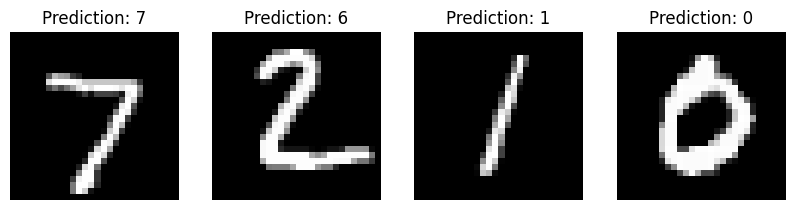

In [11]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(28, 28)
    ax.imshow(image, cmap=plt.cm.gray, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")


In [12]:
print(
    f"Classification report for classifier {clf}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

Classification report for classifier LogisticRegression(C=0.0008333333333333334, l1_ratio=1, solver='saga', tol=0.1):
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       980
           1       0.74      0.97      0.84      1135
           2       0.81      0.63      0.71      1032
           3       0.68      0.76      0.72      1010
           4       0.71      0.77      0.74       982
           5       0.64      0.40      0.49       892
           6       0.71      0.83      0.77       958
           7       0.70      0.86      0.77      1028
           8       0.78      0.59      0.67       974
           9       0.81      0.54      0.65      1009

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.72     10000
weighted avg       0.74      0.73      0.72     10000




Confusion matrix:
[[ 922    2    2    3    3    1   33    7    7    0]
 [   0 1101   15    7    0    0    4    3    5    0]
 [  62  103  650   25   38    2   85   44   18    5]
 [  21   35   32  764    7   37   17   38   41   18]
 [  12   23    4    6  753   52   39   40   17   36]
 [  64   29   14  178   74  359   51   84   24   15]
 [  37   12   18    9   28   38  797   10    8    1]
 [  16   42   37    5   14    0    5  880    7   22]
 [  14  108   25  100   11   30   65   13  577   31]
 [  20   34    9   29  130   40   22  144   35  546]]


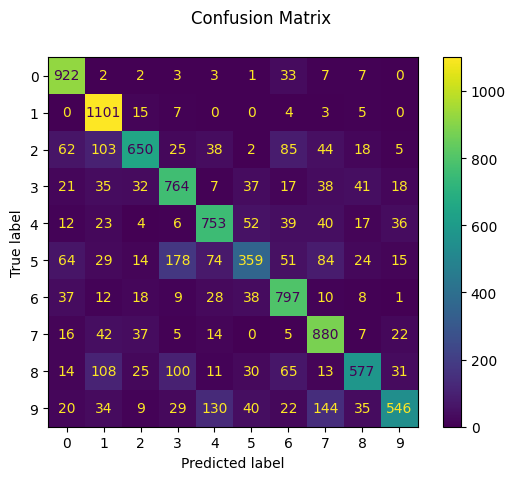

In [13]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()


# Neural net w/ trexdiff

In [14]:
from trexdiff import categorical_cross_entropy, Node, tensor2d, relu
import numpy as np

In [15]:
X_train.shape, y_train.shape

((60000, 784), (60000,))

In [16]:
# one-hot encode the labels
y_train_one_hot = np.zeros((y_train.shape[0], 10))
for i in range(y_train.shape[0]):
    y_train_one_hot[i, y_train[i]] = 1

# one-hot encode the val. labels
y_test_one_hot = np.zeros((y_test.shape[0], 10))
for i in range(y_test.shape[0]):
    y_test_one_hot[i, y_test[i]] = 1

In [17]:
def glorot(fan_in, fan_out):
    limit = np.sqrt(2.0 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, (fan_in, fan_out))

In [18]:
N_NEURONS = 40
BATCH_SIZE = 2000

np.random.seed(11)

x = Node(tensor2d(X_train[:BATCH_SIZE]))
y = Node(tensor2d(y_train_one_hot[:BATCH_SIZE]))
# _y_val = Node(tensor2d(np.zeros((y_val_one_hot.shape[0], 10))))

eps = 1e-7

w0 = Node(tensor2d(glorot(X_train.shape[1], N_NEURONS)))
w1 = Node(tensor2d(glorot(N_NEURONS, 10)))

b0 = Node(tensor2d(np.random.normal(0, 1, size=(1, N_NEURONS))))
b1 = Node(tensor2d(np.random.normal(0, 1, size=(1, 10))))

layer1 = relu(x @ w0 + b0)
logits = layer1 @ w1 + b1

loss = categorical_cross_entropy(logits, y)

In [19]:
def inference(x):
    _xs = tensor2d(x.tolist())
    _layer1 = (_xs @ w0.val + b0.val).relu()
    _logits = _layer1 @ w1.val + b1.val

    # softmax, num. stable
    logits_np = np.array(_logits.tolist())
    logits_max = logits_np.max(axis=1, keepdims=True)
    logits_stable = logits_np - logits_max

    exp_logits = np.exp(logits_stable)
    softmax = exp_logits / (np.sum(exp_logits, axis=1, keepdims=True))

    return softmax

def val_loss():
    # val loss using _inference
    probs = inference(X_test)
    loss_val = -np.sum(y_test_one_hot * np.log(probs + eps))
    loss_val /= y_test_one_hot.shape[0]
    return loss_val

In [20]:
loss.forward()
loss

[NVBLAS] NVBLAS_CONFIG_FILE environment variable is set to '../nvblas.conf'


Node(val=tensor2d([
  [2.70]
]), grad=tensor2d([
  [0.00]
]))

In [21]:
val_loss()

np.float64(2.6957471799448296)

In [22]:
lr = 0.2
momentum = 0.9
N_EPOCHS = 20

weights = [w0, w1, b0, b1]

for w in weights:
    w.velocity = tensor2d.zeros(*w.val.shape)

losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    indices = np.random.permutation(len(X_train))
    epoch_loss = 0.0

    for start in tqdm(range(0, len(X_train), BATCH_SIZE)):
        batch = indices[start:start + BATCH_SIZE]

        x.val.copy_from(tensor2d(X_train[batch]))
        y.val.copy_from(tensor2d(y_train_one_hot[batch]))

        loss.zerograd()
        loss.forward()
        loss.backward()
        epoch_loss += loss.val[0, 0]

        for w in weights:
            w.velocity = momentum * w.velocity - lr * w.grad
            w.val += w.velocity

    epoch_loss /= len(X_train) // BATCH_SIZE
    validation_loss = val_loss()

    losses.append(epoch_loss)
    val_losses.append(validation_loss)

    print(
        f"epoch {epoch + 1}, "
        f"loss: {epoch_loss:.6f}, "
        f"val_loss: {validation_loss:.6f}"
    )

  0%|          | 0/30 [00:00<?, ?it/s]

epoch 1, loss: 1.045406, val_loss: 0.406588


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 2, loss: 0.345542, val_loss: 0.284831


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 3, loss: 0.272432, val_loss: 0.248997


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 4, loss: 0.239602, val_loss: 0.224208


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 5, loss: 0.218977, val_loss: 0.208996


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 6, loss: 0.199988, val_loss: 0.193774


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 7, loss: 0.184215, val_loss: 0.185148


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 8, loss: 0.173075, val_loss: 0.167189


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 9, loss: 0.160062, val_loss: 0.161021


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 10, loss: 0.151761, val_loss: 0.153901


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 11, loss: 0.145636, val_loss: 0.148294


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 12, loss: 0.137578, val_loss: 0.143651


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 13, loss: 0.130423, val_loss: 0.136429


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 14, loss: 0.124833, val_loss: 0.136769


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 15, loss: 0.122205, val_loss: 0.133653


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 16, loss: 0.115739, val_loss: 0.131505


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 17, loss: 0.111862, val_loss: 0.131014


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 18, loss: 0.109028, val_loss: 0.129377


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 19, loss: 0.105791, val_loss: 0.127636


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 20, loss: 0.102982, val_loss: 0.124095


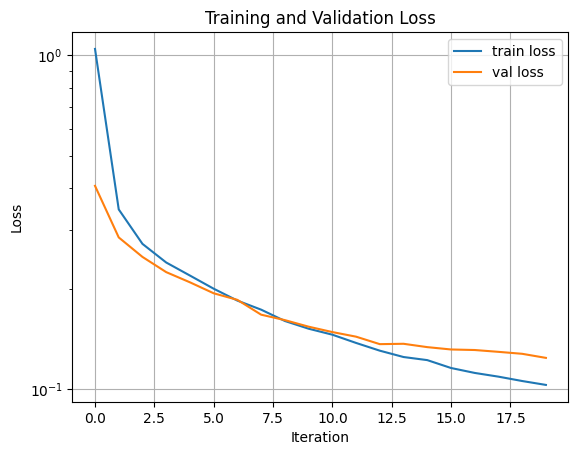

In [23]:
# plot lossses
plt.plot(losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.yscale('log')

In [24]:
nn_predicted = inference(X_test).argmax(axis=1)

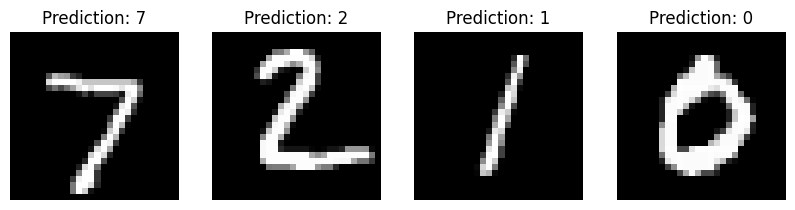

In [25]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, nn_predicted):
    ax.set_axis_off()
    image = image.reshape(28, 28)
    ax.imshow(image, cmap=plt.cm.gray, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")


In [26]:
X_train.shape

(60000, 784)

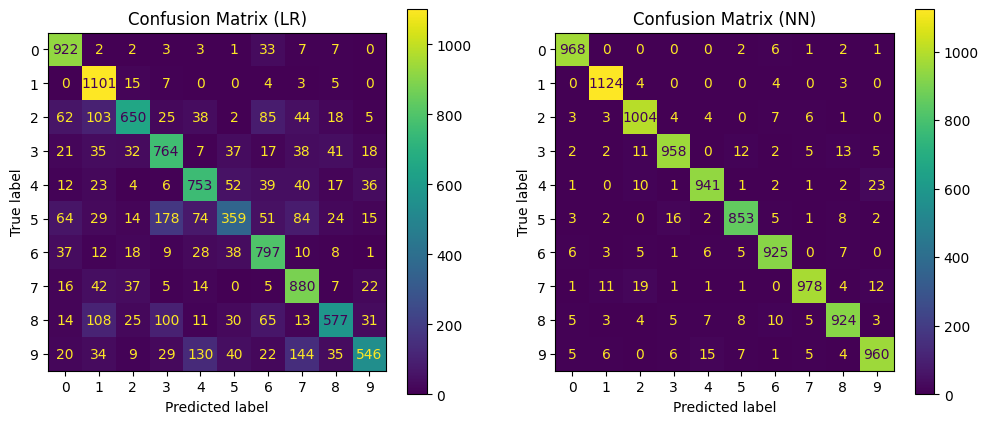

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted, ax=ax[0])
ax[0].set_title("Confusion Matrix (LR)")

disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, nn_predicted, ax=ax[1])
ax[1].set_title("Confusion Matrix (NN)")
plt.show()


In [28]:
# %load draw_digits.py